# DPO — Figures dédiées au rapport docx

Génère 3 figures polies pour la section DPO du `Compte_rendu_ADL.docx` :

1. **fig_dpo_macro.png** — évolution de la macro-accuracy ETHICS sur les 6 configurations
2. **fig_dpo_categories.png** — accuracy par catégorie, baseline vs DPO max
3. **fig_dpo_delta.png** — Δ par catégorie, PKU full vs ETHICS max (transfer négatif vs positif)

Les PNG sortent dans `../results/` et sont embarqués dans la docx.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CURRENT  = Path('../results')
LEGACY   = Path('../versions_precedentes/results')
RESULTS  = CURRENT  # figures are saved alongside the current run

def load(path):
    with open(path, encoding='utf-8') as f:
        return json.load(f)

# Current run reads from ../results/ ; historical runs from versions_precedentes/.
RUNS = {
    'Baseline':        (CURRENT / 'baseline_eval_rtx.json',     '#7f7f7f'),
    'DPO PKU full':    (LEGACY  / 'dpo_eval.json',              '#d62728'),
    'DPO PKU step-200':(LEGACY  / 'dpo_eval_rtx_step200.json',  '#ff9896'),
    'DPO ETHICS v1':   (LEGACY  / 'dpo_eval_ethics.json',       '#c5e8c5'),
    'DPO ETHICS v2':   (LEGACY  / 'dpo_eval_ethics_v2.json',    '#74c476'),
    'DPO ETHICS max':  (CURRENT / 'dpo_eval_ethics_max.json',   '#2ca02c'),
}
data = {label: (load(p), color) for label, (p, color) in RUNS.items()}

CATS = ['commonsense', 'deontology', 'justice', 'virtue']
BASELINE = data['Baseline'][0]['summary']
MAX_RUN = data['DPO ETHICS max'][0]['summary']
PKU_RUN = data['DPO PKU full'][0]['summary']

plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Macro-accuracy sur les 6 configurations

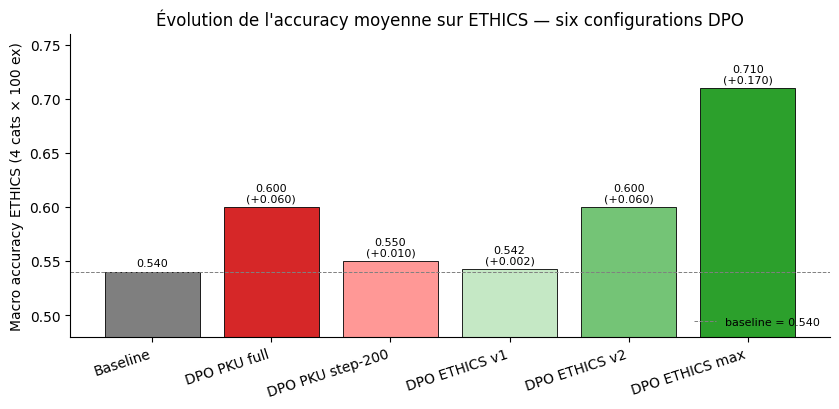

In [2]:
labels  = list(data.keys())
macros  = [data[l][0]['summary']['macro_avg'] for l in labels]
colors  = [data[l][1] for l in labels]
baseline_macro = macros[0]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
bars = ax.bar(range(len(labels)), macros, color=colors, edgecolor='black', linewidth=0.6)
ax.axhline(baseline_macro, color='gray', linestyle='--', linewidth=0.7, label=f'baseline = {baseline_macro:.3f}')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=18, ha='right')
ax.set_ylabel('Macro accuracy ETHICS (4 cats × 100 ex)')
ax.set_ylim(0.48, 0.76)
ax.set_title('Évolution de l\'accuracy moyenne sur ETHICS — six configurations DPO')
ax.legend(loc='lower right', fontsize=8, frameon=False)
for bar, val in zip(bars, macros):
    delta = val - baseline_macro
    label = f'{val:.3f}' if delta == 0 else f'{val:.3f}\n({delta:+.3f})'
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005, label, ha='center', fontsize=8, linespacing=1.1)
plt.tight_layout()
plt.savefig(RESULTS / 'fig_dpo_macro.png', dpi=170, bbox_inches='tight')
plt.show()

## 2. Accuracy par catégorie — baseline vs DPO max

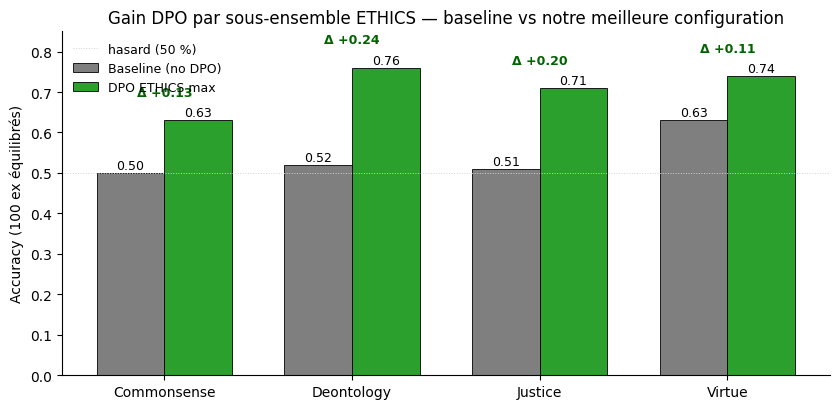

In [3]:
x = np.arange(len(CATS))
width = 0.36
base_vals = [BASELINE['per_category'][c]['accuracy'] for c in CATS]
max_vals  = [MAX_RUN['per_category'][c]['accuracy']  for c in CATS]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
b1 = ax.bar(x - width/2, base_vals, width, label='Baseline (no DPO)', color='#7f7f7f', edgecolor='black', linewidth=0.6)
b2 = ax.bar(x + width/2, max_vals,  width, label='DPO ETHICS max',    color='#2ca02c', edgecolor='black', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in CATS])
ax.set_ylabel('Accuracy (100 ex équilibrés)')
ax.set_ylim(0, 0.85)
ax.axhline(0.5, color='lightgray', linestyle=':', linewidth=0.7, label='hasard (50 %)')
ax.set_title('Gain DPO par sous-ensemble ETHICS — baseline vs notre meilleure configuration')
ax.legend(loc='upper left', fontsize=9, frameon=False)
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center', fontsize=9)
for xi, (bv, mv) in enumerate(zip(base_vals, max_vals)):
    ax.annotate(f'Δ {mv - bv:+.2f}', xy=(xi, max(bv, mv) + 0.06), ha='center', fontsize=9, color='darkgreen', weight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'fig_dpo_categories.png', dpi=170, bbox_inches='tight')
plt.show()

## 3. Δ par catégorie — PKU full vs ETHICS max

Le contraste central du rapport DPO : la même algorithmique avec un dataset out-of-distribution (PKU-SafeRLHF, safety-RLHF générique) dégrade ETHICS, tandis qu'avec un dataset in-distribution (ETHICS train reformaté en préfs DPO) elle améliore massivement.

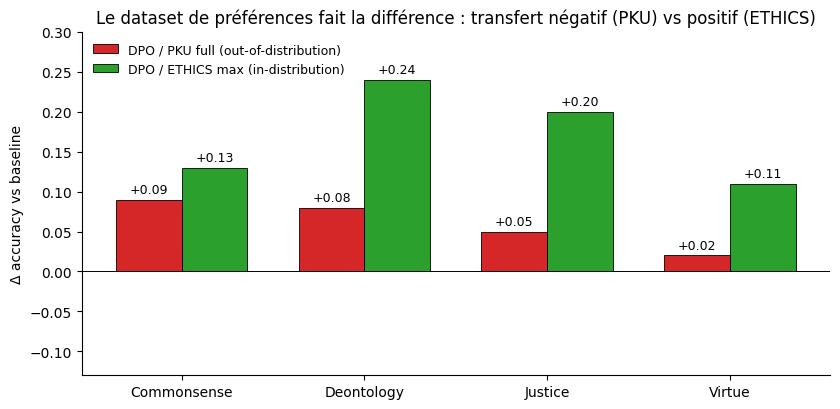

In [4]:
delta_pku  = [PKU_RUN['per_category'][c]['accuracy'] - BASELINE['per_category'][c]['accuracy'] for c in CATS]
delta_max  = [MAX_RUN['per_category'][c]['accuracy'] - BASELINE['per_category'][c]['accuracy'] for c in CATS]

x = np.arange(len(CATS))
width = 0.36
fig, ax = plt.subplots(figsize=(8.5, 4.2))
b1 = ax.bar(x - width/2, delta_pku, width, label='DPO / PKU full (out-of-distribution)', color='#d62728', edgecolor='black', linewidth=0.6)
b2 = ax.bar(x + width/2, delta_max, width, label='DPO / ETHICS max (in-distribution)',   color='#2ca02c', edgecolor='black', linewidth=0.6)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in CATS])
ax.set_ylabel('Δ accuracy vs baseline')
ax.set_ylim(-0.13, 0.30)
ax.set_title('Le dataset de préférences fait la différence : transfert négatif (PKU) vs positif (ETHICS)')
ax.legend(loc='upper left', fontsize=9, frameon=False)
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + (0.008 if h >= 0 else -0.018), f'{h:+.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / 'fig_dpo_delta.png', dpi=170, bbox_inches='tight')
plt.show()